# Sprint 1 — Análise Exploratória e Descritiva
### Classificação do Desempenho das Empresas Comerciais Brasileiras nos Cenários de Pré-Pandemia, Pandemia e Retomada (2017–2023)

**Base de dados:** Tabela 1407 — Dados gerais das empresas comerciais por grandes regiões e unidades da federação de atuação das empresas e divisão de comércio e grupo de atividade (Pesquisa Anual de Comércio — IBGE/SIDRA).
Repositório: https://sidra.ibge.gov.br/Tabela/1407

**Entregas da Sprint 1 cobertas neste notebook:**

| Entrega | Onde está |
|---|---|
| 1. A base de dados selecionada | Seção *Passo 1* (descrição) e o arquivo `tabela1407.xlsx` |
| 2. A análise exploratória e descritiva dos dados (código) | Seções 1 a 9 |
| 3. Os gráficos e visualizações, com suas interpretações | Seções 3 a 10 — cada gráfico é seguido da sua leitura; a seção 10 desce ao nível dos 18 nichos de atividade |

As etapas de pré-processamento (dados ausentes, ruídos, outliers e transformações) ficam reservadas para a Sprint 2.


## Passo 1 — Escolha e descrição da base de dados

| Item do roteiro | Descrição |
|---|---|
| **Base escolhida** | Tabela 1407 — Dados gerais das empresas comerciais por grandes regiões e unidades da federação de atuação das empresas e divisão de comércio e grupo de atividade. Base real, pública e oficial. |
| **Origem** | IBGE — Pesquisa Anual de Comércio (PAC), obtida no SIDRA: https://sidra.ibge.gov.br/Tabela/1407 |
| **Contexto** | A PAC acompanha anualmente a estrutura e o desempenho das empresas comerciais do país. A série 2017–2023 permite comparar três cenários: **pré-pandemia** (2017–2019), **pandemia** (2020–2022) e **retomada** (2023). Os valores monetários estão em R$ mil correntes, ou seja, nominais e sem deflacionar. |
| **Formato** | Arquivo Excel (`tabela1407.xlsx`, cerca de 200 KB) com 6 abas: 5 de dados (uma por variável) e a aba *Notas* (legenda dos símbolos do IBGE). Em cada aba de dados, as linhas são as 23 categorias de atividade e as colunas cruzam 7 anos × 33 geografias (formato "largo"). |
| **Tamanho da base bruta** | Após a reestruturação (seção 1), antes de qualquer recorte: **5.313 registros × 11 colunas** = 23 categorias × 33 geografias (Brasil, 5 regiões, 27 UFs) × 7 anos. |
| **Recorte usado na análise** | Por decisão do projeto (seção 1.1), a análise exclui as regiões **Norte e Nordeste** (16 UFs). A base analisada tem **2.415 registros** (15 geografias: Brasil, 3 regiões e 11 UFs), dos quais **1.134 trazem dados de fato** (ver seção 2). |
| **Objetivo** | **Classificação supervisionada:** classificar o desempenho das empresas comerciais em classes (queda / estável / crescimento) em cada cenário. A variável-alvo será derivada das variações percentuais dos indicadores (pessoal ocupado e/ou unidades locais — ver seção 4) e ainda não existe na base. |
| **Unidade de análise** | Um registro = uma combinação de categoria de atividade × geografia × ano. |

**Instâncias:** 5.313 registros na base bruta; 2.415 após o recorte geográfico (seção 1.1); 1.134 com dados de fato (seção 2).
**Atributos:** 11 colunas — 6 numéricas (o ano e 5 indicadores) e 5 categóricas.

| Atributo | Tipo | Descrição / unidade |
|---|---|---|
| `categoria` | categórico nominal (23 níveis, hierárquico) | Divisão de comércio e grupo de atividade: 1. Total; 2. Veículos; 3. Atacado (3.1 a 3.8, com 3.5.1 e 3.5.2); 4. Varejo (4.1 a 4.7, com 4.1.1 e 4.1.2) |
| `geografia` | categórico nominal (33 níveis; 15 após o recorte da seção 1.1) | Brasil, 5 grandes regiões e 27 unidades da federação |
| `ano` | numérico discreto (temporal) | 2017 a 2023 |
| `unidades_locais` | numérico discreto | Nº de unidades locais com receita de revenda (unidades) |
| `pessoal_ocupado` | numérico discreto | Pessoal ocupado em 31/12 (pessoas) |
| `gastos_salarios` | numérico contínuo | Salários, retiradas e outras remunerações (R$ mil) |
| `margem_comercializacao` | numérico contínuo | Receita líquida de revenda menos o custo da mercadoria vendida (R$ mil) |
| `receita_bruta` | numérico contínuo | Receita bruta de revenda de mercadorias (R$ mil) |
| `periodo` | categórico ordinal (derivado) | Pré-pandemia < Pandemia < Retomada |
| `nivel_geografico` | categórico nominal (derivado) | Brasil / Região / UF |
| `macrorregiao` | categórico nominal (derivado) | Grande região a que a geografia pertence |


In [1]:
%pip install -q pandas numpy matplotlib seaborn openpyxl


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", lambda x: f"{x:,.1f}".replace(",", "_").replace(".", ",").replace("_", "."))  # padrão BR, sem notação científica

# Caminho do arquivo bruto baixado do SIDRA (ajuste se necessário)
DATA_PATH = "tabela1407.xlsx"

def fmt_num(x, pos=None):
    # separador de milhar no padrão BR, para rótulos de eixo em escala log
    return f"{x:,.0f}".replace(",", ".")


## 1. Carregamento e reestruturação dos dados

A planilha original vem no formato "largo" do SIDRA: cada uma das 5 abas de dados é uma variável, com as categorias de atividade nas linhas e o cruzamento **ano × geografia** nas colunas. Antes de qualquer análise, é preciso transformar isso em uma tabela "tidy" — uma linha por combinação (categoria, geografia, ano), com as 5 variáveis como colunas.


In [3]:
REGIAO_POR_UF = {
    'Rondônia': 'Região Norte', 'Acre': 'Região Norte', 'Amazonas': 'Região Norte',
    'Roraima': 'Região Norte', 'Pará': 'Região Norte', 'Amapá': 'Região Norte',
    'Tocantins': 'Região Norte',
    'Maranhão': 'Região Nordeste', 'Piauí': 'Região Nordeste', 'Ceará': 'Região Nordeste',
    'Rio Grande do Norte': 'Região Nordeste', 'Paraíba': 'Região Nordeste',
    'Pernambuco': 'Região Nordeste', 'Alagoas': 'Região Nordeste', 'Sergipe': 'Região Nordeste',
    'Bahia': 'Região Nordeste',
    'Minas Gerais': 'Região Sudeste', 'Espírito Santo': 'Região Sudeste',
    'Rio de Janeiro': 'Região Sudeste', 'São Paulo': 'Região Sudeste',
    'Paraná': 'Região Sul', 'Santa Catarina': 'Região Sul', 'Rio Grande do Sul': 'Região Sul',
    'Mato Grosso do Sul': 'Região Centro-Oeste', 'Mato Grosso': 'Região Centro-Oeste',
    'Goiás': 'Região Centro-Oeste', 'Distrito Federal': 'Região Centro-Oeste',
}

NOMES_CURTOS = {
    'Número de unidades locais com receita de revenda': 'unidades_locais',
    'Pessoal ocupado em 31/12 em empresas comerciais': 'pessoal_ocupado',
    'Gastos com salários, retiradas e outras remunerações em empresas comerciais': 'gastos_salarios',
    'Margem de comercialização em empresas comerciais': 'margem_comercializacao',
    'Receita bruta de revenda de mercadorias': 'receita_bruta',
}

def periodo_do_ano(ano):
    if ano <= 2019:
        return 'Pré-pandemia'
    elif ano <= 2022:
        return 'Pandemia'
    return 'Retomada'

def limpar_valor(v):
    # Converte os símbolos do IBGE/SIDRA (ver aba 'Notas') em valores numéricos ou NaN.
    if isinstance(v, str):
        v = v.strip()
        if v == '-':
            return 0.0          # zero absoluto (estrutural, não é dado faltante)
        if v in ('X', '..', '...'):
            return np.nan        # sigiloso / não se aplica / não disponível -> tratar como ausente
        v = v.replace('.', '').replace(',', '.')
        try:
            return float(v)
        except ValueError:
            return np.nan
    return v


In [4]:
def parse_sheet(path, sheet_name):
    # Transforma uma aba (uma variável) do arquivo bruto do SIDRA em formato longo.
    df = pd.read_excel(path, sheet_name=sheet_name, header=None)
    variavel = str(df.iloc[1, 0]).replace('Variável - ', '').strip()

    row_ano, row_geo = df.iloc[3], df.iloc[4]
    anos_cols = [c for c in range(4, df.shape[1]) if pd.notna(row_ano[c])]

    col0 = df[0].astype(str)
    fim_idx = col0[col0.str.contains('Fonte', na=False)].index
    fim = fim_idx[0] if len(fim_idx) else len(df)
    categorias = df.iloc[5:fim, 3].tolist()

    registros = []
    for ano_col in anos_cols:
        ano = int(row_ano[ano_col])
        # dentro de cada bloco de ano, as geografias vêm a cada 2 colunas (valor, unidade)
        geo_cols = [c for c in range(ano_col, ano_col + 66, 2) if pd.notna(row_geo[c])]
        for geo_col in geo_cols:
            geografia = row_geo[geo_col]
            for i, categoria in enumerate(categorias):
                valor = limpar_valor(df.iloc[5 + i, geo_col])
                registros.append((variavel, categoria, geografia, ano, valor))
    return pd.DataFrame(registros, columns=['variavel', 'categoria', 'geografia', 'ano', 'valor'])


def carregar_base(path):
    xls = pd.ExcelFile(path)
    sheets = [s for s in xls.sheet_names if s != 'Notas']
    long_df = pd.concat([parse_sheet(path, s) for s in sheets], ignore_index=True)

    wide = long_df.pivot_table(
        index=['categoria', 'geografia', 'ano'], columns='variavel',
        values='valor', aggfunc='first'
    ).reset_index()
    wide.columns.name = None
    wide = wide.rename(columns=NOMES_CURTOS)

    wide['periodo'] = pd.Categorical(
        wide['ano'].apply(periodo_do_ano),
        categories=['Pré-pandemia', 'Pandemia', 'Retomada'], ordered=True
    )
    wide['nivel_geografico'] = wide['geografia'].apply(
        lambda g: 'Brasil' if g == 'Brasil' else ('Região' if g.startswith('Região') else 'UF')
    )
    wide['macrorregiao'] = wide['geografia'].map(REGIAO_POR_UF)
    wide.loc[wide['nivel_geografico'] == 'Região', 'macrorregiao'] = wide.loc[wide['nivel_geografico'] == 'Região', 'geografia']
    wide.loc[wide['nivel_geografico'] == 'Brasil', 'macrorregiao'] = 'Brasil'
    return wide


df = carregar_base(DATA_PATH)
print(f"Base reestruturada: {df.shape[0]} linhas x {df.shape[1]} colunas")
df.head()


Base reestruturada: 5313 linhas x 11 colunas


,categoria,geografia,ano,gastos_salarios,margem_comercializacao,unidades_locais,pessoal_ocupado,receita_bruta,periodo,nivel_geografico,macrorregiao
0,1. Total,Acre,2017,"378.703,0","1.504.909,0","2.253,0","18.677,0","6.100.495,0",Pré-pandemia,UF,Região Norte
1,1. Total,Acre,2018,"405.822,0","1.559.364,0","2.236,0","18.621,0","6.856.758,0",Pré-pandemia,UF,Região Norte
2,1. Total,Acre,2019,"389.075,0","1.594.276,0","2.098,0","18.034,0","7.014.019,0",Pré-pandemia,UF,Região Norte
3,1. Total,Acre,2020,"433.694,0","1.871.693,0","2.257,0","19.827,0","7.915.438,0",Pandemia,UF,Região Norte
4,1. Total,Acre,2021,"468.303,0","2.259.361,0","2.359,0","19.321,0","9.327.029,0",Pandemia,UF,Região Norte


## 1.1 Recorte geográfico: exclusão de Norte e Nordeste

**Decisão do projeto:** as regiões **Norte e Nordeste** (16 UFs) serão excluídas do restante da análise. A partir daqui, `df` contém apenas Brasil, as regiões Sudeste, Sul e Centro-Oeste, e as 11 UFs dessas três regiões.

**Ressalva importante (ver seção 2 para os números):** o detalhamento por subgrupo de atividade (categorias 3.x e 4.x) só existe em 6 UFs — Minas Gerais, Paraná, Rio de Janeiro, Rio Grande do Sul, Santa Catarina e São Paulo — e essa limitação **não é exclusiva do Norte/Nordeste**: das 21 UFs sem esse detalhamento, 5 (Espírito Santo e as 4 UFs do Centro-Oeste) permanecem na base mesmo depois deste recorte. Ou seja, excluir Norte e Nordeste reduz o volume de zeros estruturais, mas não elimina essa limitação. Por isso, nesta sprint, as comparações por atividade (seção 8) usam apenas os 3 grandes grupos, disponíveis nas 11 UFs.


In [5]:
REGIOES_EXCLUIDAS = ['Região Norte', 'Região Nordeste']
UFS_EXCLUIDAS = sorted(uf for uf, reg in REGIAO_POR_UF.items() if reg in REGIOES_EXCLUIDAS)

antes = len(df)
df = df[~df['geografia'].isin(REGIOES_EXCLUIDAS + UFS_EXCLUIDAS)].reset_index(drop=True)

print(f"UFs excluídas ({len(UFS_EXCLUIDAS)}): {UFS_EXCLUIDAS}")
print(f"Registros: {antes} -> {len(df)} (removidos {antes - len(df)})")
print("\nGeografias mantidas:", sorted(df['geografia'].unique()))
print("\nUFs mantidas por macrorregião:")
print(df[df['nivel_geografico'] == 'UF'].groupby('macrorregiao')['geografia'].nunique().to_string())


UFs excluídas (16): ['Acre', 'Alagoas', 'Amapá', 'Amazonas', 'Bahia', 'Ceará', 'Maranhão', 'Paraíba', 'Pará', 'Pernambuco', 'Piauí', 'Rio Grande do Norte', 'Rondônia', 'Roraima', 'Sergipe', 'Tocantins']
Registros: 5313 -> 2415 (removidos 2898)

Geografias mantidas: ['Brasil', 'Distrito Federal', 'Espírito Santo', 'Goiás', 'Mato Grosso', 'Mato Grosso do Sul', 'Minas Gerais', 'Paraná', 'Região Centro-Oeste', 'Região Sudeste', 'Região Sul', 'Rio Grande do Sul', 'Rio de Janeiro', 'Santa Catarina', 'São Paulo']

UFs mantidas por macrorregião:
macrorregiao
Região Centro-Oeste    4
Região Sudeste         4
Região Sul             3


## 2. Panorama geral e verificação de qualidade dos dados

Antes de plotar qualquer gráfico, é essencial entender a cobertura real da base: quantas categorias, geografias e anos existem, e se há alguma limitação estrutural nos dados.


In [6]:
variaveis = ['unidades_locais', 'pessoal_ocupado', 'gastos_salarios', 'margem_comercializacao', 'receita_bruta']
titulos = ['Nº de unidades locais', 'Pessoal ocupado', 'Gastos com salários (R$ mil)',
           'Margem de comercialização (R$ mil)', 'Receita bruta de revenda (R$ mil)']

print("Categorias (grupos de atividade):", df['categoria'].nunique())
print("Anos:", sorted(int(a) for a in df['ano'].unique()))
print()
resumo_nivel = (
    df.groupby('nivel_geografico')
    .agg(geografias_unicas=('geografia', 'nunique'), registros=('geografia', 'size'))
    .reindex(['Brasil', 'Região', 'UF'])
)
print("Geografias únicas e registros (= geografias × 23 categorias × 7 anos) por nível:")
print(resumo_nivel.to_string())

sem_dado = (df[variaveis] == 0).all(axis=1)
print(f"\nRegistros com as 5 variáveis iguais a zero (sem dado publicado): {int(sem_dado.sum())} de {len(df)} ({sem_dado.mean():.0%})")

print("\nEstatísticas descritivas — base inteira (distorcida pelos zeros estruturais: mediana e 25% caem em 0):")
display(df[variaveis].describe().round(1))
print("Estatísticas descritivas — só os registros com dado de fato:")
df.loc[~sem_dado, variaveis].describe().round(1)


Categorias (grupos de atividade): 23
Anos: [2017, 2018, 2019, 2020, 2021, 2022, 2023]

Geografias únicas e registros (= geografias × 23 categorias × 7 anos) por nível:
                  geografias_unicas  registros
nivel_geografico                              
Brasil                            1        161
Região                            3        483
UF                               11       1771

Registros com as 5 variáveis iguais a zero (sem dado publicado): 1281 de 2415 (53%)

Estatísticas descritivas — base inteira (distorcida pelos zeros estruturais: mediana e 25% caem em 0):


,unidades_locais,pessoal_ocupado,gastos_salarios,margem_comercializacao,receita_bruta
count,"2.415,0","2.415,0","2.415,0","2.415,0","2.415,0"
mean,"19.118,2","123.339,1","3.425.318,5","13.348.804,4","66.826.077,8"
std,"104.795,1","664.451,9","18.480.180,2","72.925.643,2","360.502.801,1"
min,"0,0","0,0","0,0","0,0","0,0"
25%,"0,0","0,0","0,0","0,0","0,0"
50%,"0,0","0,0","0,0","0,0","0,0"
75%,"4.675,0","36.467,5","1.134.311,5","5.371.928,0","32.474.198,0"
max,"1.702.147,0","10.545.204,0","352.656.650,0","1.551.681.704,0","7.697.487.334,0"


Estatísticas descritivas — só os registros com dado de fato:


,unidades_locais,pessoal_ocupado,gastos_salarios,margem_comercializacao,receita_bruta
count,"1.134,0","1.134,0","1.134,0","1.134,0","1.134,0"
mean,"40.714,7","262.666,6","7.294.659,9","28.428.009,4","142.314.795,4"
std,"150.061,6","950.807,5","26.446.075,6","104.412.359,5","515.895.757,2"
min,"109,0","314,0","5.329,0","0,0","26.608,0"
25%,"2.136,5","16.976,8","579.397,8","2.369.042,8","11.695.983,0"
50%,"6.339,0","42.147,0","1.283.181,0","5.862.118,5","36.167.454,0"
75%,"21.682,0","149.371,0","4.301.450,8","17.033.706,5","87.472.661,0"
max,"1.702.147,0","10.545.204,0","352.656.650,0","1.551.681.704,0","7.697.487.334,0"


**Achado importante de qualidade dos dados:** ao verificar os valores `-` (zero absoluto, conforme a aba *Notas* do arquivo original), percebe-se que a base tem uma cobertura bem mais restrita do que o formato sugere:

- **Brasil e as 3 grandes regiões mantidas (Sudeste, Sul, Centro-Oeste):** só a categoria **"1. Total"** tem dados; todos os grupos e subgrupos aparecem como zero.
- **As 11 UFs mantidas:** todas têm dados para **"1. Total"** e para os **3 grandes grupos** (2. veículos, 3. atacado, 4. varejo).
- **Subgrupos 3.x e 4.x (19 categorias):** só **6 das 11 UFs** (MG, PR, RJ, RS, SC e SP) têm dados; nas outras 5 UFs mantidas (ES, DF, GO, MS, MT) todos aparecem como zero.

Esses zeros não são zeros reais, e sim ausência de publicação do dado naquele nível (o tratamento fica para a Sprint 2). Duas consequências: (i) na primeira tabela de `describe()` acima, como 53% das linhas são zero, o percentil 25 e a mediana caem exatamente em 0 — só a segunda tabela (registros com dado) descreve a distribuição real; (ii) **decisão de análise:** comparações por grupo de atividade (veículos / atacado / varejo) usam o nível UF e os 3 grandes grupos, e Brasil e regiões só são usados para a categoria **"1. Total"**.


In [7]:
agregados = df[df['nivel_geografico'].isin(['Brasil', 'Região'])]
pct_zero_por_categoria = (
    agregados[agregados['categoria'] != '1. Total']
    .groupby('categoria')['receita_bruta']
    .apply(lambda s: (s == 0).mean())
)
print("% de zeros estruturais por categoria em Brasil/Região (deveria ser ~100%):")
print(pct_zero_por_categoria.round(2).to_string())
print(f"\nRegistros com dado de fato: {int((~sem_dado).sum())} de {len(df)}")


% de zeros estruturais por categoria em Brasil/Região (deveria ser ~100%):
categoria
2. Comércio de veículos, peças e motocicletas                                                           1,0
3. Comércio por atacado                                                                                 1,0
3.1 Representantes e agentes do comércio (exceto de veículos e motocicletas)                            1,0
3.2 Comércio de matérias-primas agrícolas e animais vivos                                               1,0
3.3 Produtos alimentícios, bebidas e fumo                                                               1,0
3.4 Comércio de equipamentos e artigos de uso pessoal e doméstico                                       1,0
3.5 Comércio de produtos intermediários, resíduos e sucatas                                             1,0
3.5.1 Combustíveis e lubrificantes                                                                      1,0
3.5.2 Outros produtos intermediários               

In [8]:
# Subconjuntos usados no restante da análise
total_todos_niveis = df[df['categoria'] == '1. Total'].copy()      # Brasil, Regiões e UFs — só a categoria Total
uf_total = total_todos_niveis[total_todos_niveis['nivel_geografico'] == 'UF'].copy()  # 11 UFs, categoria Total
uf_categorias = df[df['nivel_geografico'] == 'UF'].copy()           # 11 UFs, 23 categorias (subgrupos 3.x/4.x só têm dados em 6 UFs)

print("uf_total:", uf_total.shape, "| uf_categorias:", uf_categorias.shape)


uf_total: (77, 11) | uf_categorias: (1771, 11)


## 3. Distribuições das variáveis (histogramas)

Distribuição dos 5 indicadores econômicos entre as 11 UFs mantidas (categoria "1. Total", todos os anos).


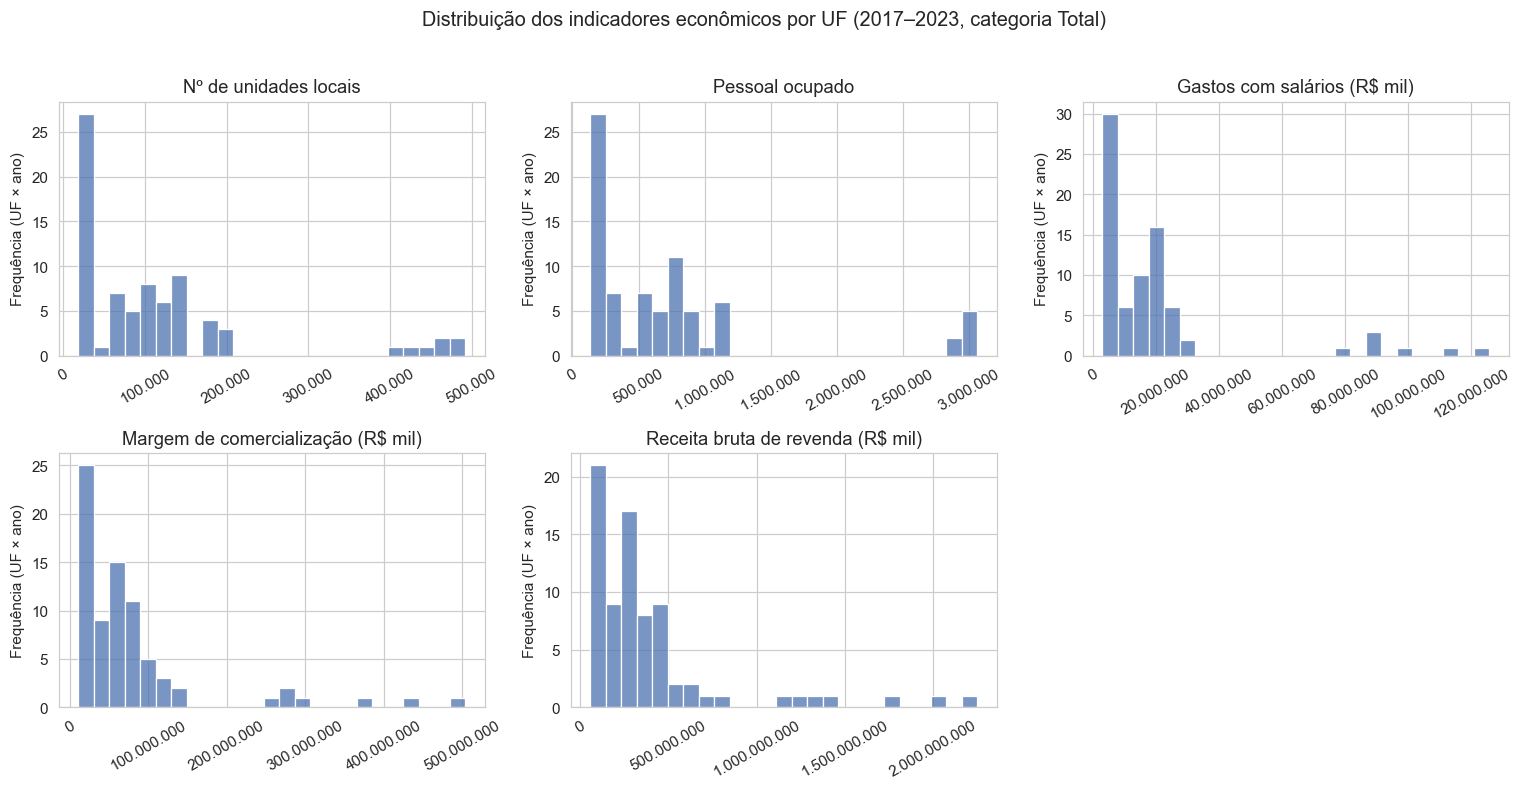

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, var, titulo in zip(axes.flat, variaveis, titulos):
    sns.histplot(uf_total[var], bins=25, ax=ax, color="#4C72B0")
    ax.set_title(titulo)
    ax.set_xlabel("")
    ax.set_ylabel("Frequência (UF × ano)")
    ax.xaxis.set_major_formatter(FuncFormatter(fmt_num))
    ax.tick_params(axis='x', rotation=30)
axes.flat[-1].axis("off")
plt.suptitle("Distribuição dos indicadores econômicos por UF (2017–2023, categoria Total)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


As distribuições são fortemente assimétricas à direita — esperado, já que estados como São Paulo concentram uma quantidade de empresas, empregos e receita muito acima da média dos demais. Isso reforça que, na etapa de pré-processamento, provavelmente será necessário normalizar/padronizar essas variáveis antes de usá-las como atributos em algoritmos sensíveis à escala.


## 4. Boxplots por período (Pré-pandemia, Pandemia, Retomada)

Em vez de olhar os níveis absolutos (que variam demais entre UFs), vamos comparar a **variação percentual ano a ano** de cada indicador — essa é a métrica que efetivamente captura o impacto da pandemia e será a base da futura variável de desempenho (a ser construída na Sprint 2).


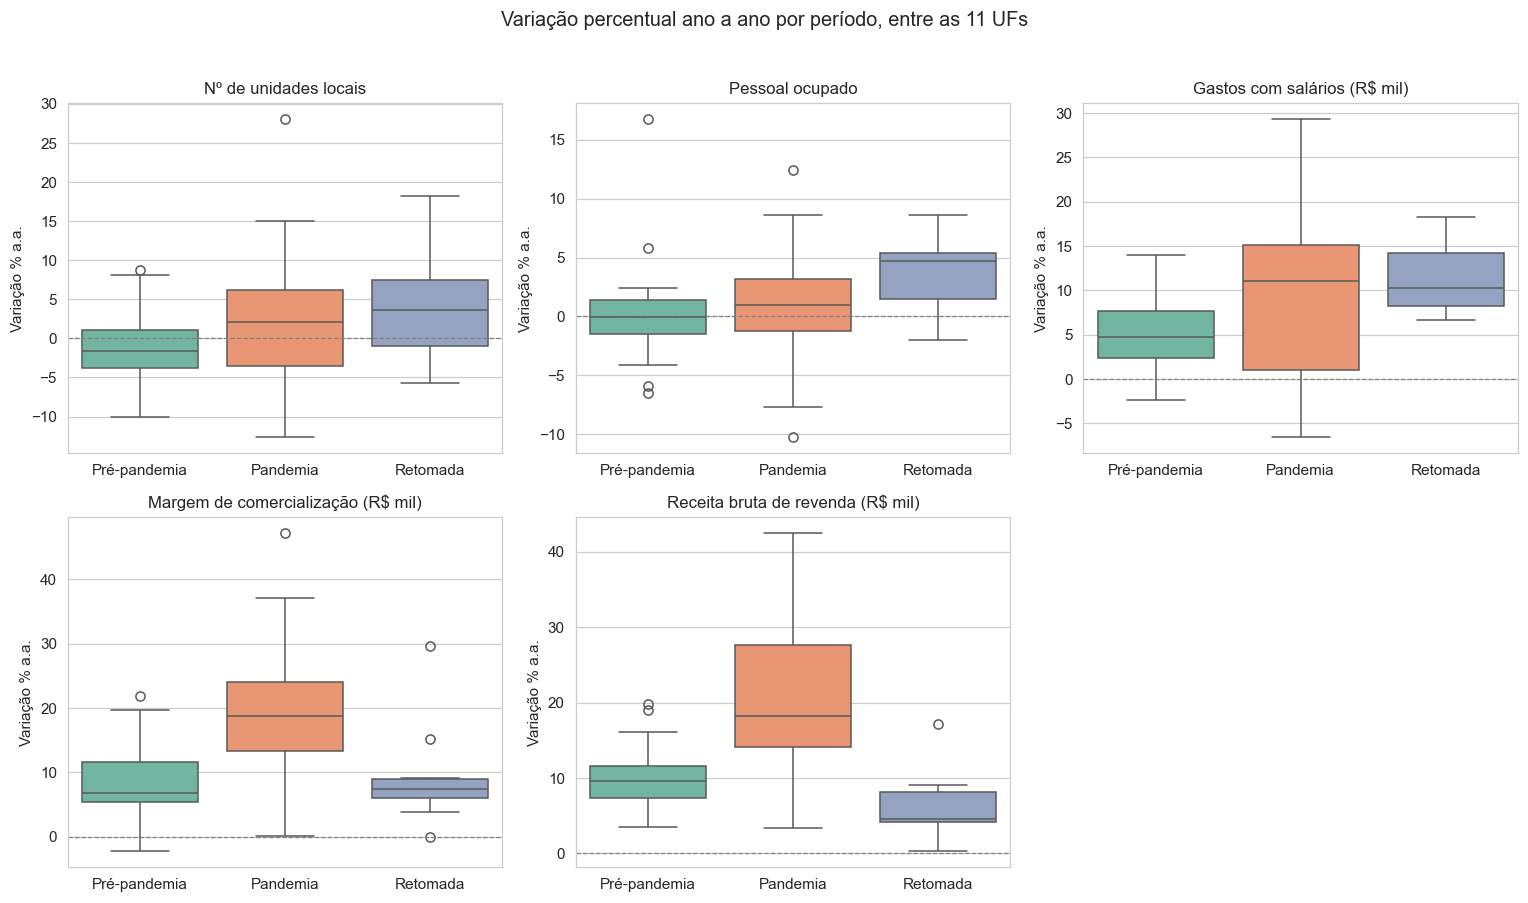

In [10]:
uf_total = uf_total.sort_values(['geografia', 'ano'])
for var in variaveis:
    uf_total[var + '_var%'] = uf_total.groupby('geografia')[var].pct_change() * 100

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, var, titulo in zip(axes.flat, variaveis, titulos):
    sns.boxplot(data=uf_total, x='periodo', y=var + '_var%', hue='periodo', palette="Set2", legend=False, ax=ax)
    ax.axhline(0, color='grey', lw=0.8, ls='--')
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Variação % a.a.")
axes.flat[-1].axis("off")
plt.suptitle("Variação percentual ano a ano por período, entre as 11 UFs", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


**Insight-chave:** a **receita bruta nominal** cresceu em praticamente todos os estados mesmo durante a pandemia (provavelmente reflexo da inflação e da migração para o comércio essencial/e-commerce). Já o **número de unidades locais** e o **pessoal ocupado** caem claramente em 2020 e só voltam a crescer com força a partir de 2021 — esses dois indicadores parecem ser sinais muito mais fiéis do impacto real da pandemia sobre o setor do que a receita nominal isoladamente. Isso é importante para a etapa de pré-processamento: a variável de desempenho (queda/estável/crescimento) talvez deva ser construída a partir de pessoal ocupado e/ou nº de unidades, não apenas da receita nominal.


## 5. Evolução temporal por macrorregião

Como cada uma das 5 variáveis evoluiu, ano a ano, por macrorregião — com destaque para o período de pandemia.


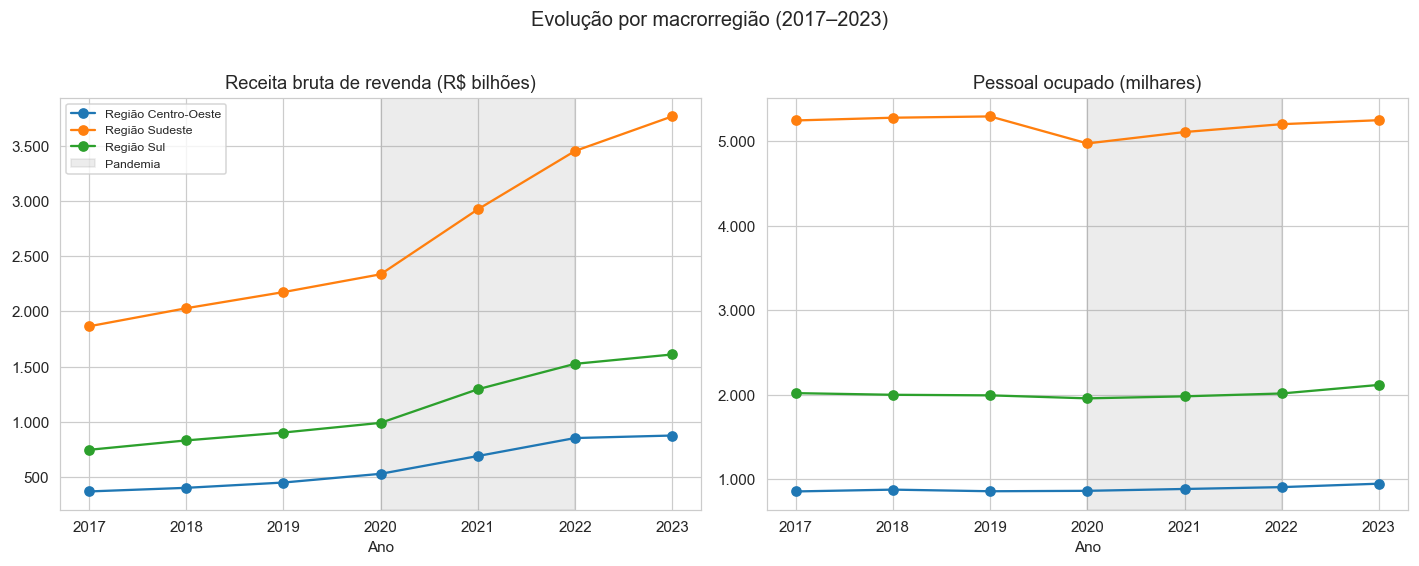

In [11]:
regiao_ano = (
    total_todos_niveis[total_todos_niveis['nivel_geografico'] == 'Região']
    .groupby(['geografia', 'ano'])[variaveis].sum().reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for geo, grupo in regiao_ano.groupby('geografia'):
    axes[0].plot(grupo['ano'], grupo['receita_bruta'] / 1e6, marker='o', label=geo)
    axes[1].plot(grupo['ano'], grupo['pessoal_ocupado'] / 1e3, marker='o', label=geo)

for ax, titulo in zip(axes, ['Receita bruta de revenda (R$ bilhões)', 'Pessoal ocupado (milhares)']):
    ax.axvspan(2020, 2022, color='grey', alpha=0.15, label='Pandemia')
    ax.set_title(titulo)
    ax.set_xlabel('Ano')
    ax.yaxis.set_major_formatter(FuncFormatter(fmt_num))

axes[0].legend(fontsize=8, loc='upper left')
plt.suptitle("Evolução por macrorregião (2017–2023)", y=1.02, fontsize=13)
plt.tight_layout()
plt.show()


A região Sudeste domina em volume absoluto (esperado, dada sua participação no PIB nacional), mas o gráfico deixa visível a **desaceleração/leve queda do pessoal ocupado em 2020 em todas as regiões**, seguida de recuperação consistente a partir de 2021 — o mesmo padrão em formato de "V" aparece em todas elas, com intensidade um pouco diferente.


## 6. Matriz de correlação entre as variáveis


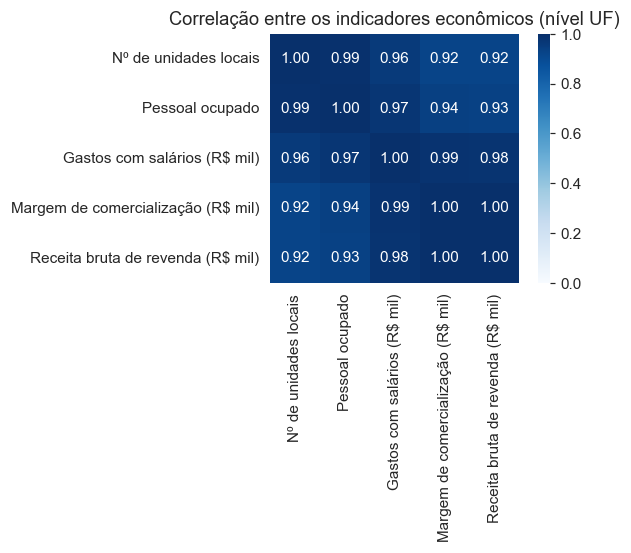

In [12]:
corr = uf_total[variaveis].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, square=True,
            xticklabels=titulos, yticklabels=titulos)
plt.title("Correlação entre os indicadores econômicos (nível UF)")
plt.tight_layout()
plt.show()


Como esperado, todas as variáveis são **fortemente correlacionadas entre si** (todas medem, de formas diferentes, o tamanho da atividade comercial de um estado). Isso é um sinal de alerta para a etapa de pré-processamento: usar as 5 variáveis em nível absoluto como atributos de um modelo traria forte multicolinearidade — pode ser mais interessante trabalhar com as **variações percentuais** ou com **razões** (ex.: receita por unidade local, receita por funcionário) em vez dos níveis brutos, e avaliar se PCA/seleção de atributos se justifica.


## 7. Gráfico de dispersão: pessoal ocupado × receita bruta

Colorido por período, para visualizar se a relação entre as duas variáveis mudou durante a pandemia. Os eixos usam escala logarítmica (com os valores reais nos rótulos) porque os estados diferem em várias ordens de grandeza.


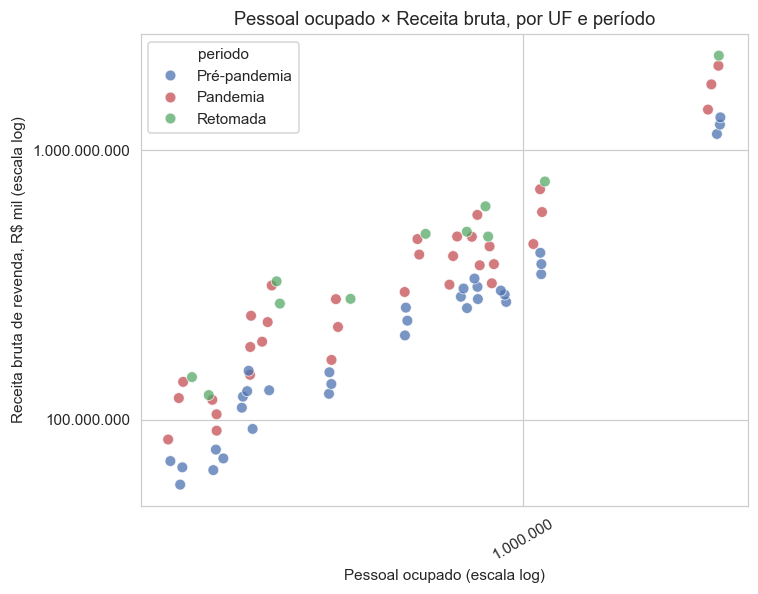

In [13]:
plt.figure(figsize=(7, 5.5))
sns.scatterplot(
    data=uf_total, x='pessoal_ocupado', y='receita_bruta',
    hue='periodo', palette={'Pré-pandemia': '#4C72B0', 'Pandemia': '#C44E52', 'Retomada': '#55A868'},
    alpha=0.75, s=50
)
plt.xscale('log')
plt.yscale('log')
plt.gca().xaxis.set_major_formatter(FuncFormatter(fmt_num))
plt.gca().yaxis.set_major_formatter(FuncFormatter(fmt_num))
plt.xticks(rotation=30)
plt.xlabel('Pessoal ocupado (escala log)')
plt.ylabel('Receita bruta de revenda, R$ mil (escala log)')
plt.title('Pessoal ocupado × Receita bruta, por UF e período')
plt.tight_layout()
plt.show()


A relação entre pessoal ocupado e receita é aproximadamente linear em escala logarítmica (o que é esperado — estados maiores têm mais empregados *e* mais receita), e os pontos dos três períodos ficam bastante misturados, sem um deslocamento visual óbvio. Isso confirma que os efeitos da pandemia aparecem melhor na **variação ao longo do tempo por estado** (seção 4) do que na relação estática entre as variáveis.


## 8. Comparação por grupo de atividade (veículos, atacado, varejo)

Usando apenas o nível UF (o único com detalhamento por grande grupo de atividade — ver seção 2), comparamos como cada grande grupo de atividade se comportou.


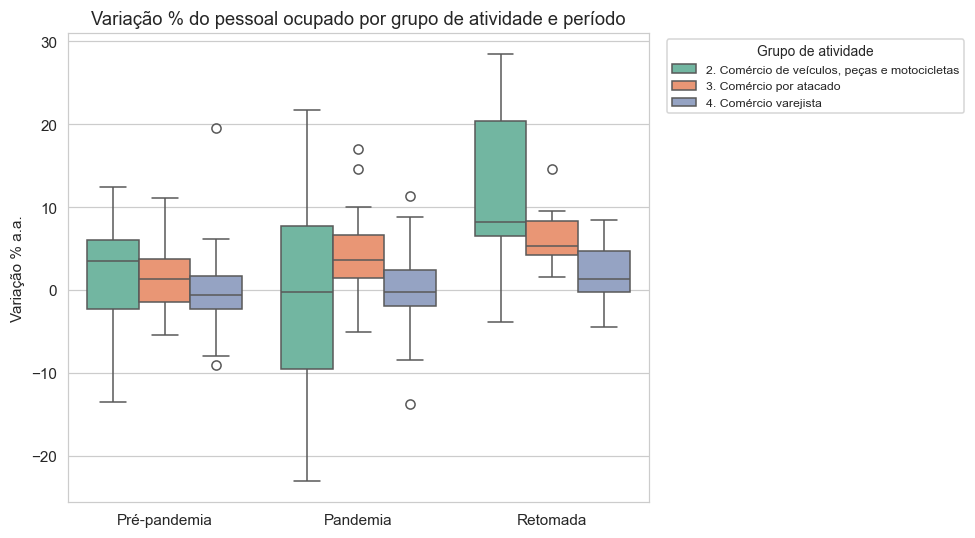

In [14]:
grupos_principais = ['2. Comércio de veículos, peças e motocicletas', '3. Comércio por atacado', '4. Comércio varejista']
uf_grupos = uf_categorias[uf_categorias['categoria'].isin(grupos_principais)].copy()
uf_grupos = uf_grupos.sort_values(['categoria', 'geografia', 'ano'])
uf_grupos['pessoal_var%'] = uf_grupos.groupby(['categoria', 'geografia'])['pessoal_ocupado'].pct_change() * 100

plt.figure(figsize=(9, 5))
sns.boxplot(data=uf_grupos, x='periodo', y='pessoal_var%', hue='categoria', palette="Set2")
plt.title('Variação % do pessoal ocupado por grupo de atividade e período')
plt.ylabel('Variação % a.a.')
plt.xlabel('')
plt.legend(title='Grupo de atividade', fontsize=8, title_fontsize=9, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


Esse recorte por grupo de atividade é o mais interessante para a proposta: o **comércio de veículos** (mais sensível a bens duráveis e cadeias de suprimento) é o grupo mais volátil — tem a maior dispersão na pandemia e o maior salto na retomada — enquanto **atacado** e **varejo** (que incluem itens essenciais) oscilam muito menos. Essa distinção deve aparecer com força na modelagem de classificação nas próximas sprints.


## 9. Ranking: UFs mais afetadas em 2020 e com maior recuperação em 2023

Usando o **pessoal ocupado** (indicador mais fiel ao impacto real, ver seção 4) como referência.


In [15]:
queda_2020 = (
    uf_total[uf_total['ano'] == 2020][['geografia', 'macrorregiao', 'pessoal_ocupado_var%']]
    .sort_values('pessoal_ocupado_var%')
    .rename(columns={'pessoal_ocupado_var%': 'variação % pessoal ocupado 2020'})
)
print("5 UFs com maior queda de pessoal ocupado em 2020:")
print(queda_2020.head(5).to_string(index=False))

crescimento_2023 = (
    uf_total[uf_total['ano'] == 2023][['geografia', 'macrorregiao', 'pessoal_ocupado_var%']]
    .sort_values('pessoal_ocupado_var%', ascending=False)
    .rename(columns={'pessoal_ocupado_var%': 'variação % pessoal ocupado 2023'})
)
print("\n5 UFs com maior crescimento de pessoal ocupado em 2023 (retomada):")
print(crescimento_2023.head(5).to_string(index=False))


5 UFs com maior queda de pessoal ocupado em 2020:
        geografia   macrorregiao  variação % pessoal ocupado 2020
   Espírito Santo Região Sudeste                            -10,3
Rio Grande do Sul     Região Sul                             -7,7
        São Paulo Região Sudeste                             -6,8
   Rio de Janeiro Região Sudeste                             -5,0
     Minas Gerais Região Sudeste                             -3,9

5 UFs com maior crescimento de pessoal ocupado em 2023 (retomada):
         geografia        macrorregiao  variação % pessoal ocupado 2023
             Goiás Região Centro-Oeste                              8,6
    Espírito Santo      Região Sudeste                              7,2
 Rio Grande do Sul          Região Sul                              5,6
Mato Grosso do Sul Região Centro-Oeste                              5,1
    Santa Catarina          Região Sul                              4,7


**Leitura:** as maiores quedas de pessoal ocupado em 2020 se concentram no Sudeste e no Sul (Espírito Santo, Rio Grande do Sul e São Paulo lideram), enquanto a retomada de 2023 é puxada pelo Centro-Oeste (Goiás e Mato Grosso do Sul) e, de novo, pelo Espírito Santo — que, por ter caído mais, também recupera mais. Esse comportamento do ES (grande oscilação em anos seguidos) merece atenção na Sprint 2, ao definir a variável-alvo.


## 10. Os três períodos: visão macro e visão micro dos mercados

As seções 3 a 9 olham os indicadores ano a ano. Aqui reorganizamos a leitura pelos **três cenários do projeto** e em duas camadas:

- **Macro** — o comércio como um todo e os 3 grandes grupos (veículos, atacado, varejo), nas 11 UFs, em cada período;
- **Micro** — como estava cada um dos **18 nichos de atividade** (veículos + 9 de atacado + 8 de varejo, sem contar duas vezes os totais) em cada período. Os nichos só existem nas 6 UFs com detalhamento (SP, MG, RJ, PR, SC, RS), que são somadas para formar um "mercado" por nicho.

Para comparar períodos de durações diferentes, a métrica é a **média anual de variação** dentro de cada um: pré-pandemia = 2017→2019 (2 anos), pandemia = 2019→2022 (3 anos), retomada = 2022→2023 (1 ano). Os valores de receita são nominais; o IPCA acumulado de 2019 a 2023 foi de cerca de 27% (≈6% ao ano), referência para separar crescimento real de inflação.


In [16]:
PERIODOS = {'Pré-pandemia\n2017→2019': (2017, 2019), 'Pandemia\n2019→2022': (2019, 2022), 'Retomada\n2022→2023': (2022, 2023)}
COR_PERIODO = {'Pré-pandemia\n2017→2019': '#4C72B0', 'Pandemia\n2019→2022': '#C44E52', 'Retomada\n2022→2023': '#55A868'}

NICHOS = {
    '2.': 'Veículos, peças e motos', '3.1': 'Atac. representantes/agentes', '3.2': 'Atac. matérias-primas agrícolas',
    '3.3': 'Atac. alimentos, bebidas e fumo', '3.4': 'Atac. uso pessoal e doméstico', '3.5.1': 'Atac. combustíveis',
    '3.5.2': 'Atac. outros intermediários', '3.6': 'Atac. equipamentos de TI', '3.7': 'Atac. máquinas e equipamentos',
    '3.8': 'Atac. não-especializado', '4.1.1': 'Var. hiper/supermercado', '4.1.2': 'Var. outros não-especializados',
    '4.2': 'Var. alimentos, bebidas e fumo', '4.3': 'Var. vestuário e calçados', '4.4': 'Var. combustíveis',
    '4.5': 'Var. informática', '4.6': 'Var. outros em lojas especializadas', '4.7': 'Var. artigos usados',
}

uf_all = df[df['nivel_geografico'] == 'UF'].copy()
uf_all['cod'] = uf_all['categoria'].str.split().str[0]
uf_all = uf_all[(uf_all[variaveis] != 0).any(axis=1)]

def media_anual(piv, a, b):
    # média anual de variação % entre os anos a e b (taxa composta)
    return ((piv[b] / piv[a]) ** (1 / (b - a)) - 1) * 100

def por_periodo(piv):
    return pd.DataFrame({p: media_anual(piv, a, b) for p, (a, b) in PERIODOS.items()})

def rotulo_periodo(p):
    return p.replace('\n', ' ')

print("Períodos:", {rotulo_periodo(p): v for p, v in PERIODOS.items()})


Períodos: {'Pré-pandemia 2017→2019': (2017, 2019), 'Pandemia 2019→2022': (2019, 2022), 'Retomada 2022→2023': (2022, 2023)}


### 10.1 Macro — os grandes grupos em cada período (11 UFs)


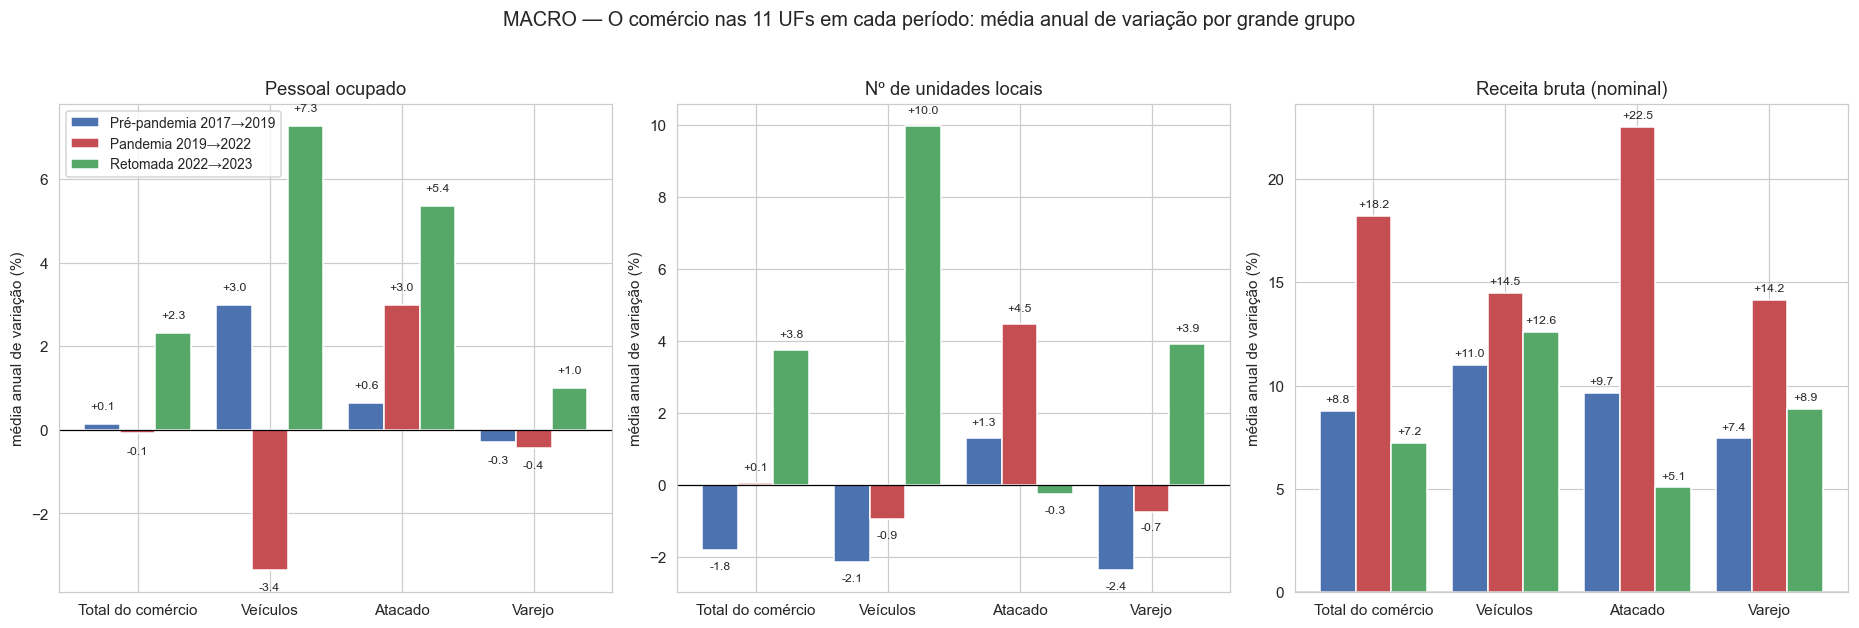

cod,Total do comércio,Veículos,Atacado,Varejo
pessoal_ocupado | Pré-pandemia 2017→2019,"0,1","3,0","0,6","-0,3"
pessoal_ocupado | Pandemia 2019→2022,"-0,1","-3,4","3,0","-0,4"
pessoal_ocupado | Retomada 2022→2023,"2,3","7,3","5,4","1,0"
unidades_locais | Pré-pandemia 2017→2019,"-1,8","-2,1","1,3","-2,4"
unidades_locais | Pandemia 2019→2022,"0,1","-0,9","4,5","-0,7"
unidades_locais | Retomada 2022→2023,"3,8","10,0","-0,3","3,9"
receita_bruta | Pré-pandemia 2017→2019,"8,8","11,0","9,7","7,4"
receita_bruta | Pandemia 2019→2022,"18,2","14,5","22,5","14,2"
receita_bruta | Retomada 2022→2023,"7,2","12,6","5,1","8,9"


In [17]:
grupos_soma = uf_all[uf_all['cod'].isin(['1.', '2.', '3.', '4.'])].groupby(['cod', 'ano'])[variaveis].sum().reset_index()
ROTULO_GRUPO = {'1.': 'Total do comércio', '2.': 'Veículos', '3.': 'Atacado', '4.': 'Varejo'}

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
for ax, var, titulo in zip(axes, ['pessoal_ocupado', 'unidades_locais', 'receita_bruta'],
                           ['Pessoal ocupado', 'Nº de unidades locais', 'Receita bruta (nominal)']):
    t = por_periodo(grupos_soma.pivot_table(index='cod', columns='ano', values=var)).rename(index=ROTULO_GRUPO).loc[list(ROTULO_GRUPO.values())]
    x = np.arange(len(t))
    for i, (per, cor) in enumerate(COR_PERIODO.items()):
        barras = ax.bar(x + (i - 1) * 0.27, t[per], 0.27, color=cor, label=rotulo_periodo(per))
        for b, v in zip(barras, t[per]):
            ax.text(b.get_x() + b.get_width() / 2, v + (0.3 if v >= 0 else -0.3), f"{v:+.1f}",
                    ha='center', va='bottom' if v >= 0 else 'top', fontsize=8)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(t.index)
    ax.set_title(titulo, fontsize=12)
    ax.set_ylabel('média anual de variação (%)')
axes[0].legend(fontsize=9, loc='upper left')
plt.suptitle('MACRO — O comércio nas 11 UFs em cada período: média anual de variação por grande grupo', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

macro = pd.concat({v: por_periodo(grupos_soma.pivot_table(index='cod', columns='ano', values=v)).rename(index=ROTULO_GRUPO)
                   for v in ['pessoal_ocupado', 'unidades_locais', 'receita_bruta']}, axis=1)
macro.columns = [f"{v} | {rotulo_periodo(p)}" for v, p in macro.columns]
display(macro.round(1).T)


**Leitura.**

- **Pré-pandemia (2017–2019):** um comércio estagnado em emprego (Total +0,1% a.a.) e que **já fechava lojas** (−1,8% a.a. de unidades locais; varejo −2,4%, veículos −2,1%). Só o atacado abria unidades (+1,3%). A receita nominal crescia perto de 9% a.a.
- **Pandemia (2019–2022):** no agregado o emprego praticamente não caiu (Total −0,1% a.a.) — mas isso é uma média que esconde a divisão: **veículos −3,4% a.a.** e varejo −0,4% contra **atacado +3,0%**. O fechamento de lojas foi congelado (Total +0,1%), e a receita nominal **dobrou de ritmo** (8,8% → 18,2% a.a.; atacado +22,5%), combinação de inflação, alta de commodities e demanda represada.
- **Retomada (2022–2023):** o emprego acelera em todos os grupos (Total +2,3%; veículos +7,3%; atacado +5,4%; varejo +1,0%) e o número de lojas volta a crescer (+3,8%, com veículos +10%), invertendo a tendência pré-pandemia. A receita desacelera para +7,2% — ou seja, o setor volta a crescer em volume, não em preço.

No agregado, portanto, a pandemia foi menos um choque de emprego e mais uma **redistribuição**: do varejo e dos veículos para o atacado.


### 10.2 Macro — cada UF em cada período (categoria Total)


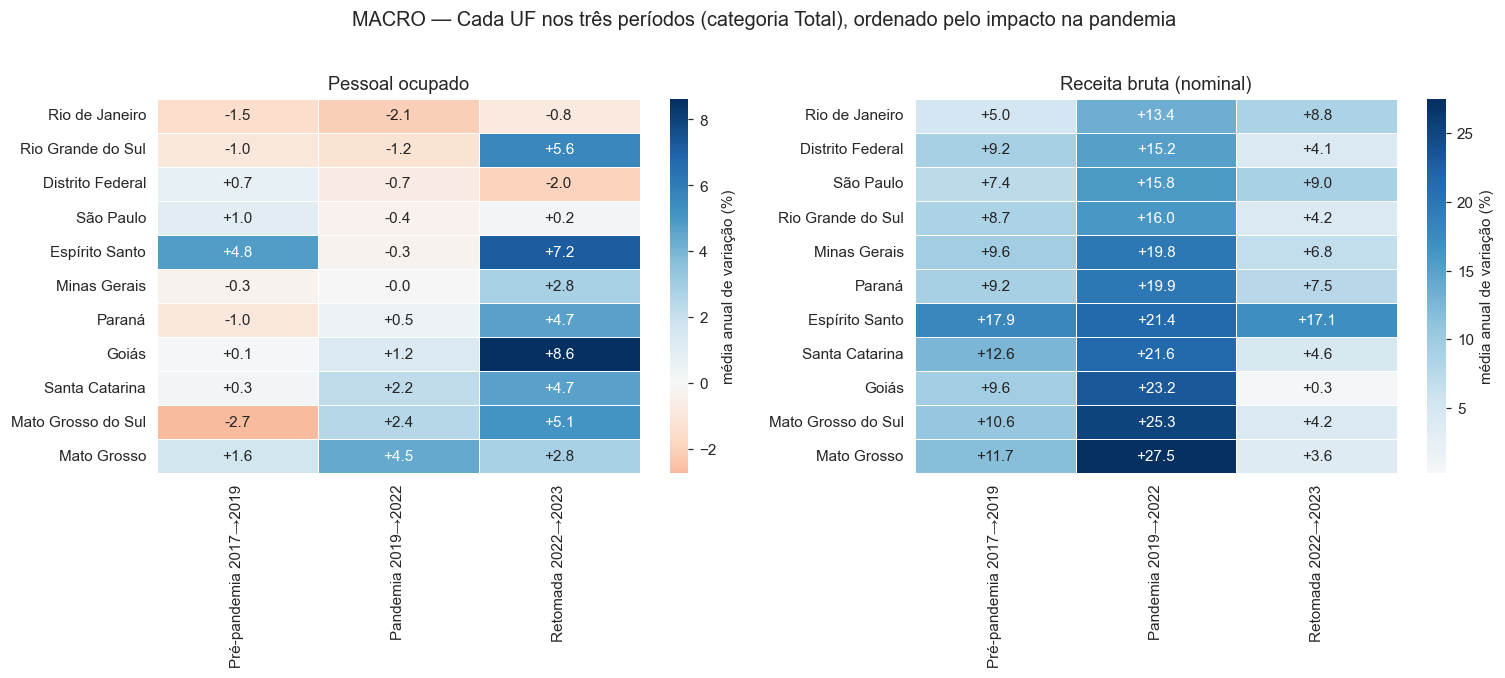

In [18]:
total_uf = uf_all[uf_all['cod'] == '1.']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, var, titulo in zip(axes, ['pessoal_ocupado', 'receita_bruta'], ['Pessoal ocupado', 'Receita bruta (nominal)']):
    t = por_periodo(total_uf.pivot_table(index='geografia', columns='ano', values=var))
    t.columns = [rotulo_periodo(c) for c in t.columns]
    t = t.sort_values(t.columns[1])
    sns.heatmap(t, annot=True, fmt='+.1f', cmap='RdBu', center=0, linewidths=0.5, ax=ax,
                cbar_kws={'label': 'média anual de variação (%)'})
    ax.set_title(titulo, fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('')
plt.suptitle('MACRO — Cada UF nos três períodos (categoria Total), ordenado pelo impacto na pandemia', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


**Leitura.**

- **Rio de Janeiro** é a única UF que perde emprego nos três períodos (−1,5 / −2,1 / −0,8% a.a.): a queda é anterior à pandemia e continua depois dela — problema estrutural local, não Covid.
- Na **pandemia**, as UFs mais urbanas perderam (RJ −2,1, RS −1,2, DF −0,7, SP −0,4), enquanto o **Centro-Oeste inteiro cresceu** (MT +4,5, MS +2,4, GO +1,2) e Santa Catarina +2,2. Na receita, todas cresceram entre 13% e 27% a.a., com os maiores ritmos justamente no Centro-Oeste (MT +27,5, MS +25,3, GO +23,2) — o ciclo do agronegócio e das commodities.
- Na **retomada**, Goiás (+8,6), Espírito Santo (+7,2), RS (+5,6) e MS (+5,1) lideram o emprego; **São Paulo fica em +0,2** (não recuperou o que perdeu) e o **Distrito Federal continua caindo (−2,0)**. O Espírito Santo é o caso mais volátil (+4,8 / −0,3 / +7,2), o que já tinha aparecido na seção 9.

Conclusão para o modelo: o mesmo período pode significar "queda" numa UF e "crescimento" em outra — a UF precisa ser atributo da classificação, não só o nicho e o ano.


### 10.3 Micro — os 18 nichos em cada período (6 UFs)


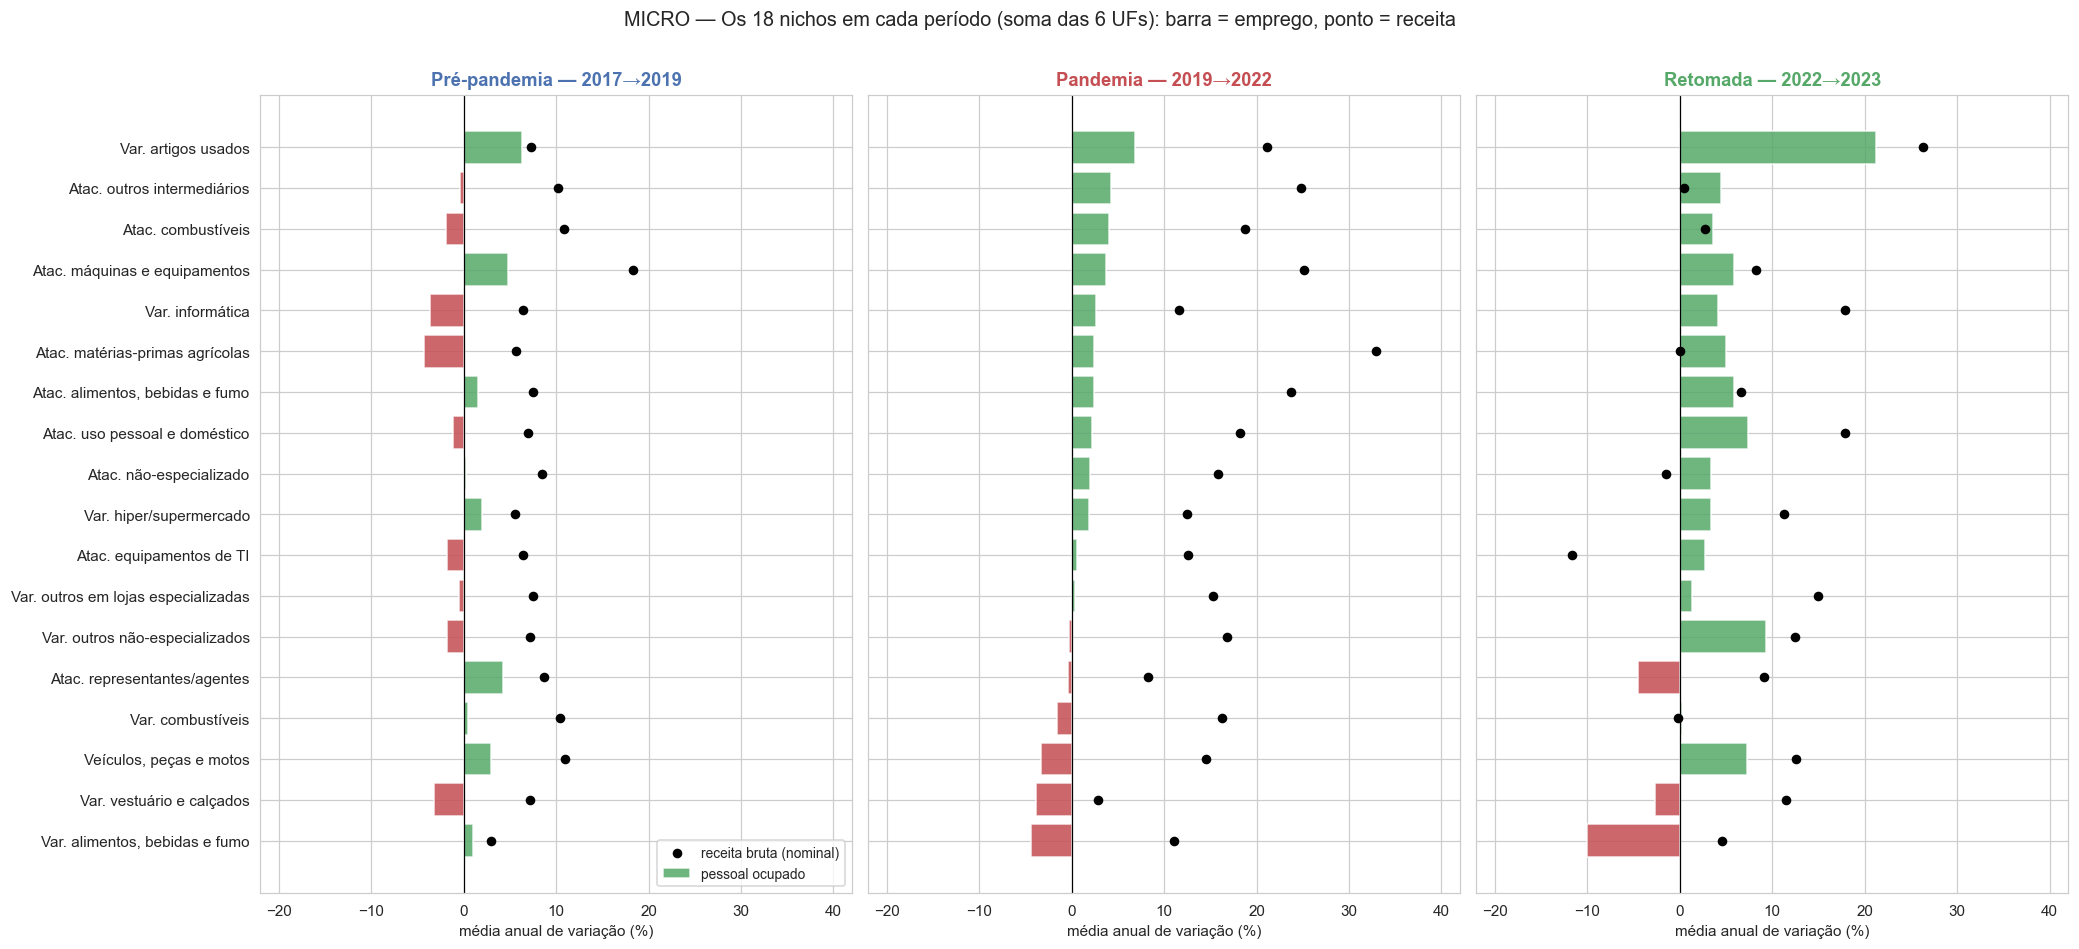

,pessoal | Pré-pandemia 2017→2019,pessoal | Pandemia 2019→2022,pessoal | Retomada 2022→2023,receita | Pré-pandemia 2017→2019,receita | Pandemia 2019→2022,receita | Retomada 2022→2023
nicho,,,,,,
"Var. alimentos, bebidas e fumo","1,0","-4,4","-10,0","3,0","11,1","4,5"
Var. vestuário e calçados,"-3,2","-3,8","-2,7","7,2","2,8","11,5"
"Veículos, peças e motos","3,0","-3,4","7,3","11,0","14,5","12,6"
Var. combustíveis,"0,5","-1,6","0,2","10,4","16,2","-0,2"
Atac. representantes/agentes,"4,2","-0,4","-4,5","8,7","8,2","9,1"
Var. outros não-especializados,"-1,8","-0,3","9,3","7,2","16,8","12,5"
Var. outros em lojas especializadas,"-0,5","0,3","1,3","7,5","15,3","14,9"
Atac. equipamentos de TI,"-1,8","0,5","2,7","6,4","12,5","-11,7"
Var. hiper/supermercado,"2,0","1,9","3,3","5,6","12,5","11,3"


In [19]:
nichos = uf_all[uf_all['cod'].isin(NICHOS)].copy()
nichos['nicho'] = nichos['cod'].map(NICHOS)
mercado = nichos.groupby(['nicho', 'ano'])[variaveis].sum().reset_index()
POR_PERIODO = {v: por_periodo(mercado.pivot_table(index='nicho', columns='ano', values=v)) for v in variaveis}
ordem_nichos = POR_PERIODO['pessoal_ocupado'].iloc[:, 1].sort_values().index   # do que mais perdeu emprego na pandemia ao que mais ganhou

fig, axes = plt.subplots(1, 3, figsize=(19, 8.5), sharey=True)
y = np.arange(len(ordem_nichos))
for ax, (per, cor) in zip(axes, COR_PERIODO.items()):
    pess = POR_PERIODO['pessoal_ocupado'].loc[ordem_nichos, per]
    rec = POR_PERIODO['receita_bruta'].loc[ordem_nichos, per]
    ax.barh(y, pess, color=np.where(pess < 0, '#C44E52', '#55A868'), alpha=0.85, label='pessoal ocupado')
    ax.scatter(rec, y, color='black', zorder=3, s=28, label='receita bruta (nominal)')
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(per.replace('\n', ' — '), fontsize=12, color=cor, fontweight='bold')
    ax.set_xlabel('média anual de variação (%)')
    ax.set_xlim(-22, 42)
axes[0].set_yticks(y)
axes[0].set_yticklabels(ordem_nichos)
axes[0].legend(loc='lower right', fontsize=9)
plt.suptitle('MICRO — Os 18 nichos em cada período (soma das 6 UFs): barra = emprego, ponto = receita', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

tab_micro = pd.concat({'pessoal': POR_PERIODO['pessoal_ocupado'], 'receita': POR_PERIODO['receita_bruta']}, axis=1).loc[ordem_nichos]
tab_micro.columns = [f"{v} | {rotulo_periodo(p)}" for v, p in tab_micro.columns]
display(tab_micro.round(1))


**Leitura, período a período.**

- **Pré-pandemia:** um mercado morno — quase todas as barras entre −4% e +5% a.a. Já **caíam** em emprego: matérias-primas agrícolas (−4,3), informática (−3,6), vestuário (−3,2), combustíveis no atacado (−2,0), TI (−1,8). Já **cresciam**: artigos usados (+6,3), máquinas e equipamentos (+4,8), representantes (+4,2), veículos (+3,0), hiper/supermercados (+2,0). A receita crescia de forma parecida em todos (5% a 11%), com exceção de máquinas (+18%).
- **Pandemia:** o gráfico vira dois blocos. **Vermelho (perderam emprego): só varejo e intermediação** — alimentos no varejo (−4,4% a.a.), vestuário (−3,8), veículos (−3,4), combustíveis no varejo (−1,6), representantes e outros não-especializados. **Verde: todo o atacado** (outros intermediários +4,3, combustíveis +4,0, máquinas +3,7, alimentos +2,4, matérias-primas +2,4), além de artigos usados (+6,9), informática (+2,6) e hiper (+1,9). A receita disparou nos atacados ligados a agro e indústria (matérias-primas +33% a.a., máquinas +25%, intermediários +25%, alimentos +24%) e ficou quase parada só em vestuário (+2,8% a.a., queda real).
- **Retomada:** quase tudo verde, mas com três exceções que importam: o **varejo de alimentos perde outros 10%** de pessoal (o único nicho que cai nos dois períodos), representantes −4,5 e vestuário −2,7. Do lado da receita, o **atacado de TI cai 11,7%** e matérias-primas, combustíveis no varejo e atacado não-especializado ficam em zero — o fim do ciclo de alta de commodities e de equipamentos do home office. Os maiores crescimentos de emprego são artigos usados (+21%), outros varejos não-especializados (+9,3), uso pessoal e doméstico (+7,4) e veículos (+7,3).


### 10.4 Micro — tendência prévia × choque: o nicho já estava caindo antes?


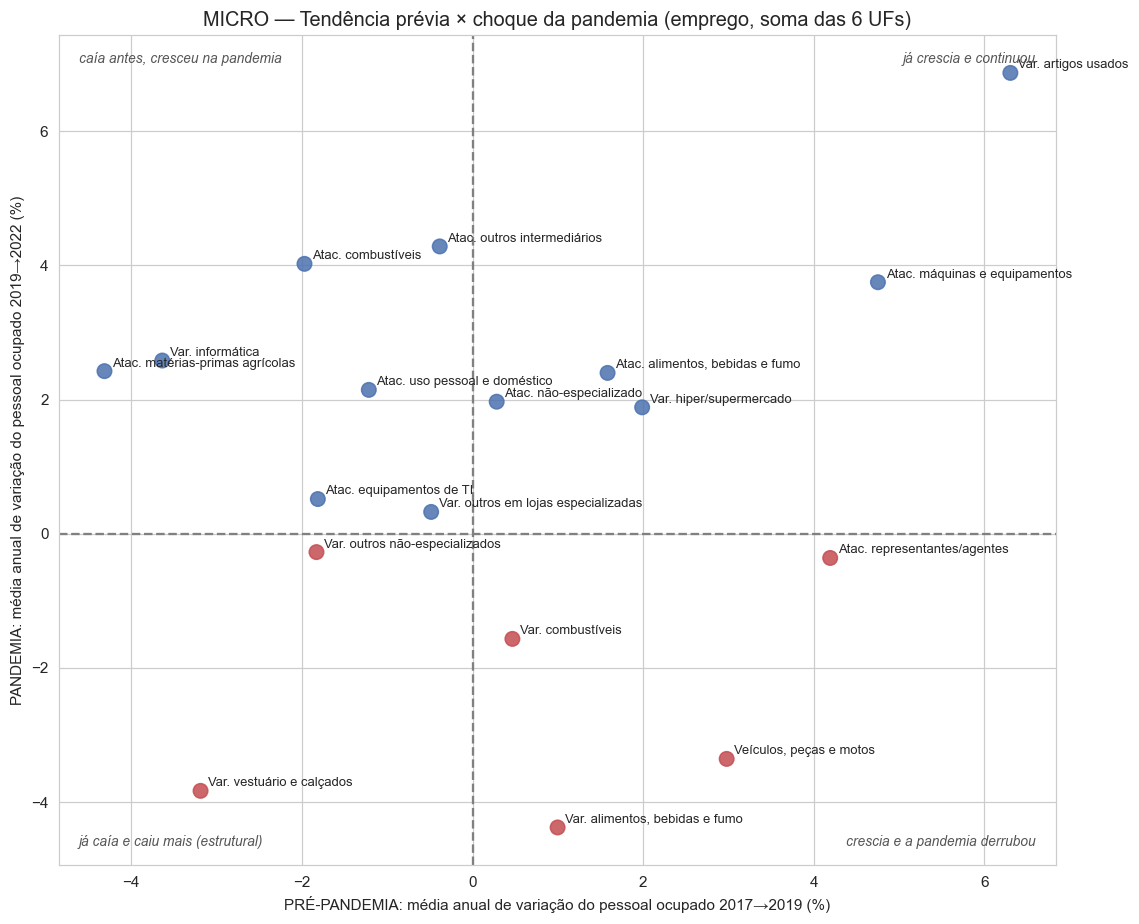

In [20]:
pre = POR_PERIODO['pessoal_ocupado'].iloc[:, 0]
pan = POR_PERIODO['pessoal_ocupado'].iloc[:, 1]

fig, ax = plt.subplots(figsize=(10.5, 8.5))
ax.axhline(0, color='grey', ls='--')
ax.axvline(0, color='grey', ls='--')
ax.scatter(pre, pan, s=90, c=np.where(pan < 0, '#C44E52', '#4C72B0'), alpha=0.85)
for nome in pre.index:
    ax.annotate(nome, (pre[nome], pan[nome]), fontsize=8.5, xytext=(5, 3), textcoords='offset points')
for xq, yq, txt in [(0.98, 0.98, 'já crescia e continuou'), (0.02, 0.98, 'caía antes, cresceu na pandemia'),
                    (0.02, 0.02, 'já caía e caiu mais (estrutural)'), (0.98, 0.02, 'crescia e a pandemia derrubou')]:
    ax.text(xq, yq, txt, transform=ax.transAxes, fontsize=9, color='#555555', style='italic',
            ha='right' if xq > 0.5 else 'left', va='top' if yq > 0.5 else 'bottom')
ax.set_xlabel('PRÉ-PANDEMIA: média anual de variação do pessoal ocupado 2017→2019 (%)')
ax.set_ylabel('PANDEMIA: média anual de variação do pessoal ocupado 2019→2022 (%)')
ax.set_title('MICRO — Tendência prévia × choque da pandemia (emprego, soma das 6 UFs)', fontsize=13)
plt.tight_layout()
plt.show()


**Leitura.** Cruzar o período anterior com o da pandemia separa o que é **choque** do que é **tendência**:

- **"Crescia e a pandemia derrubou"** (choque puro): veículos (+3,0 → −3,4), varejo de alimentos (+1,0 → −4,4), combustíveis no varejo (+0,5 → −1,6) e representantes (+4,2 → −0,4). São os candidatos naturais à classe "queda" no cenário de pandemia.
- **"Já caía e caiu mais"** (estrutural): só **vestuário e calçados** (−3,2 → −3,8). A pandemia não criou o problema do vestuário de rua, apenas o manteve — o e-commerce já vinha tirando emprego desse nicho.
- **"Caía antes e a pandemia salvou"**: informática (−3,6 → +2,6), matérias-primas agrícolas (−4,3 → +2,4), combustíveis no atacado (−2,0 → +4,0), TI (−1,8 → +0,5). Mercados que estavam em queda e foram puxados pelo home office e pelo agro.
- **"Já crescia e continuou"**: artigos usados (+6,3 → +6,9), máquinas (+4,8 → +3,7), hiper/supermercados (+2,0 → +1,9), atacado de alimentos (+1,6 → +2,4). Resilientes.

Para a variável-alvo, isso sugere que rotular o desempenho **em relação à tendência anterior do próprio nicho** (e não só em relação a zero) pode separar melhor os casos.


### 10.5 Micro — retomada: quem voltou ao nível de 2019?


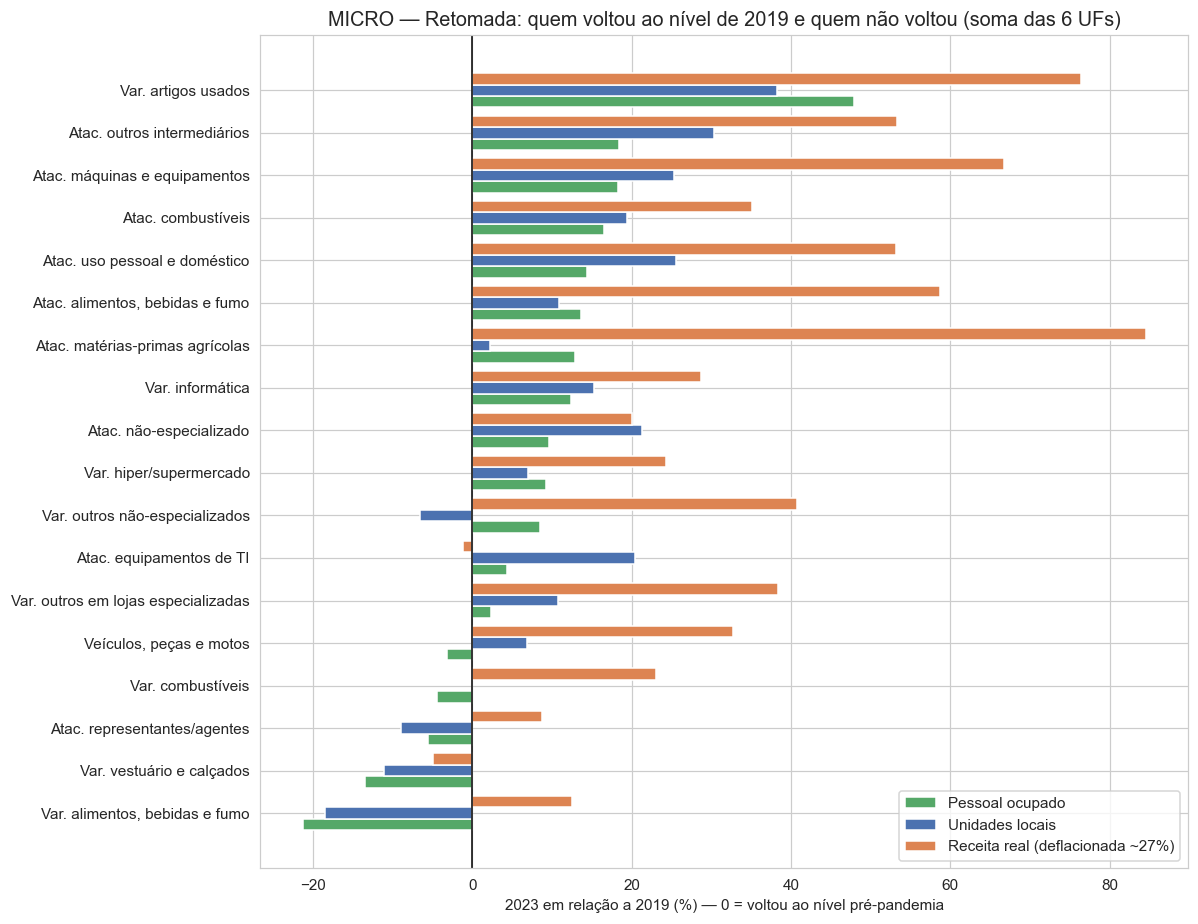

,Pessoal ocupado,Unidades locais,Receita real (deflacionada ~27%)
nicho,,,
"Var. alimentos, bebidas e fumo","-21,3","-18,5","12,5"
Var. vestuário e calçados,"-13,5","-11,2","-4,9"
Atac. representantes/agentes,"-5,5","-9,0","8,7"
Var. combustíveis,"-4,4","-0,0","23,1"
"Veículos, peças e motos","-3,2","6,9","32,8"
Var. outros em lojas especializadas,"2,3","10,8","38,3"
Atac. equipamentos de TI,"4,3","20,4","-1,1"
Var. outros não-especializados,"8,4","-6,6","40,7"
Var. hiper/supermercado,"9,3","7,0","24,3"


In [21]:
IPCA_2019_2023 = 1.273   # IPCA acumulado aproximado 2019→2023 (~27%)
piv = {v: mercado.pivot_table(index='nicho', columns='ano', values=v) for v in ['pessoal_ocupado', 'unidades_locais', 'receita_bruta']}
recuperacao = pd.DataFrame({
    'Pessoal ocupado': (piv['pessoal_ocupado'][2023] / piv['pessoal_ocupado'][2019] - 1) * 100,
    'Unidades locais': (piv['unidades_locais'][2023] / piv['unidades_locais'][2019] - 1) * 100,
    'Receita real (deflacionada ~27%)': (piv['receita_bruta'][2023] / piv['receita_bruta'][2019] / IPCA_2019_2023 - 1) * 100,
}).sort_values('Pessoal ocupado')

fig, ax = plt.subplots(figsize=(11, 8.5))
y = np.arange(len(recuperacao))
for i, (col, cor) in enumerate(zip(recuperacao.columns, ['#55A868', '#4C72B0', '#DD8452'])):
    ax.barh(y + (i - 1) * 0.27, recuperacao[col], 0.27, color=cor, label=col)
ax.axvline(0, color='black', lw=1)
ax.set_yticks(y)
ax.set_yticklabels(recuperacao.index)
ax.set_xlabel('2023 em relação a 2019 (%) — 0 = voltou ao nível pré-pandemia')
ax.set_title('MICRO — Retomada: quem voltou ao nível de 2019 e quem não voltou (soma das 6 UFs)', fontsize=13)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

display(recuperacao.round(1))


**Leitura.** Comparando 2023 diretamente com 2019 (último ano normal):

- **Não recuperaram o emprego**: varejo de alimentos (−21%), vestuário (−14%), representantes (−6%), combustíveis no varejo (−4%) e veículos (−3%). Os dois primeiros também fecharam lojas (−18% e −11% de unidades locais).
- Em **receita real** (descontada a inflação de ~27%), só dois nichos estão abaixo de 2019: **vestuário (−5%)** e **atacado de TI (−1%)** — este último subiu na pandemia e devolveu tudo em 2023. Todos os outros cresceram em termos reais, com destaque para matérias-primas (+85%), artigos usados (+76%), máquinas (+67%) e atacado de alimentos (+59%).
- O caso mais revelador é o **varejo de alimentos**: −21% de pessoas, −18% de lojas e **+12% de receita real**. O mercado não encolheu — ele **se consolidou** em lojas maiores e com menos gente. O mesmo vale, em menor grau, para veículos (−3% de pessoal, +33% de receita real).
- Os **atacados** cresceram nas três dimensões ao mesmo tempo (pessoas, lojas e receita real), o que confirma a redistribuição vista no macro (10.1).

**Cinco arquétipos de mercado** emergem dessa leitura por período e devem orientar a definição das classes na Sprint 2: (1) *atingidos e não recuperados* — varejo de alimentos, vestuário, representantes; (2) *atingidos e recuperados em V* — veículos, combustíveis no varejo; (3) *vencedores da pandemia* — atacados ligados a agro e indústria; (4) *ciclo curto* — atacado de TI; (5) *estáveis/essenciais* — hiper/supermercados, informática.


## 11. Síntese dos achados da Sprint 1 e próximos passos

- **Escopo geográfico:** por decisão do projeto (seção 1.1), Norte e Nordeste (16 UFs) foram excluídos. A análise cobre Sudeste, Sul e Centro-Oeste (11 UFs, mais Brasil e as 3 regiões como referência).
- **Cobertura dos dados:** Brasil e as 3 regiões só têm a categoria "1. Total"; nas 11 UFs, o Total e os 3 grandes grupos (veículos, atacado, varejo) estão completos, mas os 19 subgrupos 3.x e 4.x só têm dados em 6 UFs (MG, PR, RJ, RS, SC e SP). Dos 2.415 registros do recorte, 1.281 (53%) são zeros estruturais e apenas 1.134 trazem dados de fato (seção 2). O tratamento desses registros é o primeiro item da Sprint 2.
- **Receita nominal x impacto real:** a receita bruta de revenda cresceu, em termos nominais, em quase todos os estados mesmo em 2020, provavelmente por efeito de inflação e de setores essenciais. Já **pessoal ocupado** e **número de unidades locais** mostram queda real e clara em 2020, com recuperação a partir de 2021, e parecem mais adequados para basear a futura variável de desempenho (seção 4).
- **Heterogeneidade regional:** as 3 macrorregiões seguem o mesmo padrão em "V" (queda em 2020, recuperação a partir de 2021), com intensidades diferentes (seção 5).
- **Multicolinearidade:** as 5 variáveis são fortemente correlacionadas entre si (seção 6). Vale considerar razões (receita por unidade, receita por funcionário) ou as variações percentuais como atributos, em vez dos níveis absolutos.
- **Assimetria e escala:** os níveis são muito assimétricos (São Paulo domina); a relação pessoal × receita só fica linear em escala log (seções 3 e 7), o que indica a necessidade de transformação/padronização antes da modelagem.
- **Grupos de atividade:** o comércio de veículos é o mais volátil entre os três grandes grupos; atacado e varejo são mais estáveis (seção 8).
- **Os três períodos, no macro (seção 10.1–10.2):** na pré-pandemia o comércio estagnava em emprego e já fechava lojas; na pandemia o emprego agregado quase não caiu (−0,1% a.a.) porque o atacado (+3,0%) compensou veículos (−3,4%) e varejo — uma redistribuição, não um choque geral —, enquanto a receita nominal dobrou de ritmo; na retomada emprego e lojas voltam a crescer e a receita desacelera. O RJ perde emprego nos três períodos e o Centro-Oeste cresce até na pandemia.
- **Os três períodos, no micro (seção 10.3–10.5):** na pandemia só varejo e intermediação perderam emprego (alimentos −4,4% a.a., vestuário, veículos, combustíveis) e todo o atacado cresceu; cruzando com a tendência anterior, veículos e varejo de alimentos foram choque puro, vestuário é declínio estrutural e informática/agro foram "salvos" pela pandemia. Em 2023, cinco nichos ainda empregam menos que em 2019 e o varejo de alimentos se consolidou (−21% de pessoas, −18% de lojas, +12% de receita real).

**Próximos passos (Sprint 2 — pré-processamento):**
- tratar os zeros estruturais como dados ausentes (remover ou restringir o recorte) e verificar os símbolos do SIDRA (`X`, `..`, `...`);
- avaliar ruídos por consistência interna (UFs somam a região; veículos + atacado + varejo = Total; subgrupos somam o grupo) e outliers (nível, variação % e razões);
- definir formalmente a variável de desempenho (queda / estável / crescimento) e avaliar o balanceamento das classes (2020 deve concentrar as quedas);
- escolher o nível de análise para evitar dupla contagem (Total = 2 + 3 + 4; grupo 3 = soma dos 3.x) — uma opção é usar as 11 UFs × 3 grandes grupos;
- considerar deflacionar os valores monetários (por exemplo, pelo IPCA), já que a comparação entre anos hoje é nominal.
